<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    50 non-null     int64
 1   review_text  50 non-null     str  
 2   sentiment    50 non-null     str  
dtypes: int64(1), str(2)
memory usage: 1.3 KB
              precision    recall  f1-score   support

    negative       0.50      0.25      0.33         4
     neutral       0.00      0.00      0.00         2
    positive       0.38      0.75      0.50         4

    accuracy                           0.40        10
   macro avg       0.29      0.33      0.28        10
weighted avg       0.35      0.40      0.33        10



[nltk_data] Downloading package stopwords to /Users/nyuad/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/nyuad/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/Users/nyuad/jupyter-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/nyuad/jupyter-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/nyuad/jupyter-env/lib/python3.14/site-packages/sklearn/metrics/_classificat

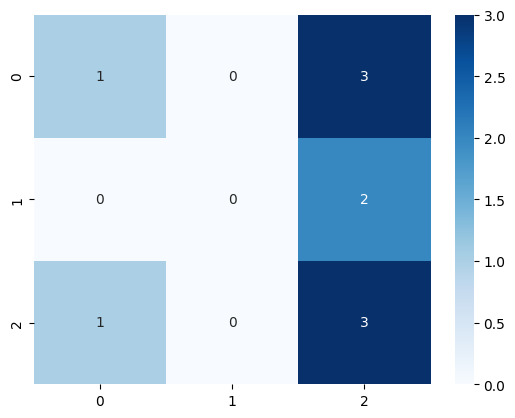

/var/folders/vb/j6km979n6zn_q3x_qmbx9xjw0000gn/T/ipykernel_1112/1510195301.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis')


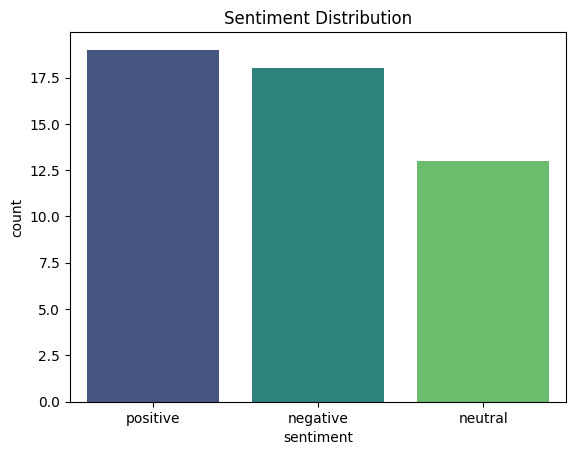

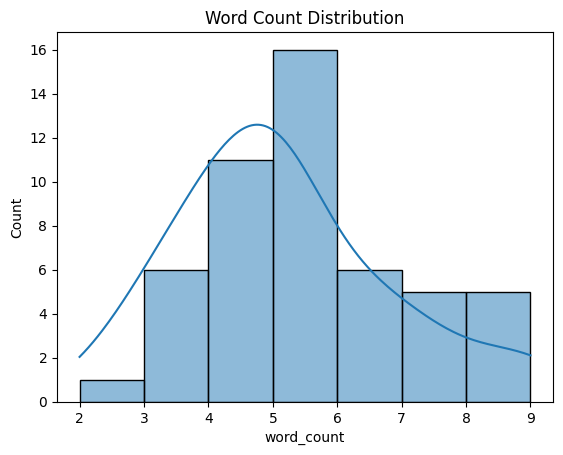

Positive: [('quality', 6), ('product', 5), ('delivery', 3), ('fast', 3), ('excellent', 3), ('happy', 3), ('purchase', 3), ('great', 3), ('customer', 2), ('service', 2), ('super', 2), ('loved', 2), ('amazing', 2), ('helpful', 1), ('polite', 1), ('match', 1), ('description', 1), ('quick', 1), ('good', 1), ('value', 1)]
Negative: [('item', 5), ('product', 4), ('arrived', 3), ('delivery', 3), ('poor', 2), ('disappointed', 1), ('damaged', 1), ('took', 1), ('long', 1), ('satisfied', 1), ('packaging', 1), ('scratched', 1), ('stopped', 1), ('working', 1), ('two', 1), ('day', 1), ('worth', 1), ('price', 1), ('color', 1), ('different', 1)]
Neutral: [('it’s', 4), ('bad', 3), ('fine', 3), ('okay', 2), ('average', 2), ('experience', 2), ('nothing', 2), ('work', 2), ('acceptable', 2), ('decent', 2), ('product', 2), ('great', 1), ('either', 1), ('special', 1), ('quality', 1), ('delivery', 1), ('time', 1), ('meet', 1), ('basic', 1), ('expectation', 1)]


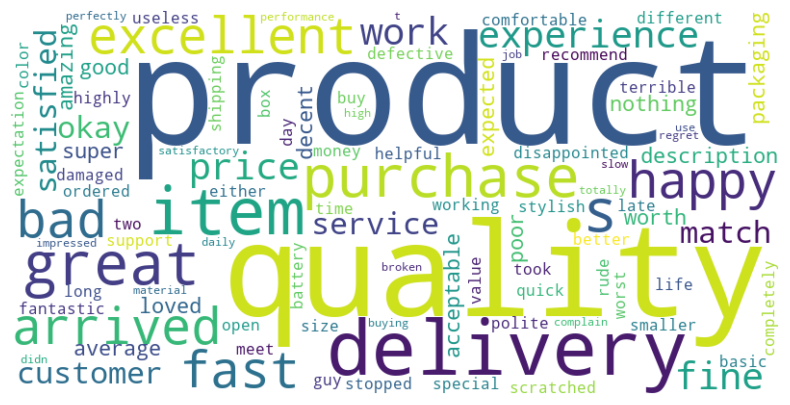

Topic #1:
['super', 'okay', 'average', 'decent', 'quality', 'experience', 'bad', 'fast', 'delivery', 'product']


Topic #2:
['amazing', 'acceptable', 'poor', 'packaging', 'price', 'work', 'arrived', 'fine', 'item', 'quality']


Topic #3:
['match', 'description', 'expected', 'customer', 'service', 'excellent', 'great', 'product', 'happy', 'purchase']




AttributeError: 'csr_matrix' object has no attribute 'lower'

In [7]:
# 1. Import Libraries
# 2. Load Dataset
# 3. Data Cleaning
# 4. Text Preprocessing
# 5. Exploratory Text Analysis (EDA)
# 6. Vectorization (TF-IDF)
# 7. Model Training (Logistic Regression)
# 8. Model Evaluation
# 9. Predict Sentiment on New Text
# 10. Export Results
# 11. Business Insights
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix



df = pd.read_csv("uae_customer_reviews.csv")
df.head()
df.info()
df['sentiment'].value_counts()
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['review_text'].apply(clean_text)
df.head()
X = df['clean_text']
y = df['sentiment']

tfidf = TfidfVectorizer()
X_vec = tfidf.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues")
plt.show()
#predict new sentiments
sample = ["The delivery was fast and the product is amazing"]
sample_clean = clean_text(sample[0])
sample_vec = tfidf.transform([sample_clean])
model.predict(sample_vec)
df['predicted_sentiment'] = model.predict(X_vec)
df.to_csv("sentiment_results.csv", index=False)
### Business Insights

#- Positive reviews highlight fast delivery and good product quality.
#- Negative reviews mainly mention damaged items and slow delivery.
#- Neutral reviews show mixed satisfaction.
#- Recommendation: Improve packaging quality and delivery speed.
#EDA SENTIMENT ANALYYSIS
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='sentiment', palette='viridis')
plt.title("Sentiment Distribution")
plt.show()
#WORD COUNT ANALYSIS
df['word_count'] = df['review_text'].apply(lambda x: len(x.split()))

sns.histplot(df['word_count'], kde=True)
plt.title("Word Count Distribution")
plt.show()
#Most Common Words (Positive / Negative / Neutral)
from collections import Counter

def get_top_words(sentiment):
    words = " ".join(df[df['sentiment']==sentiment]['clean_text']).split()
    return Counter(words).most_common(20)

print("Positive:", get_top_words("positive"))
print("Negative:", get_top_words("negative"))
print("Neutral:", get_top_words("neutral"))
#WordClouds (Very Impressive for Portfolio)
from wordcloud import WordCloud

text = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()
#LDA

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
#Convert text to tokens
vectorizer = CountVectorizer(max_df=0.9, min_df=2, stop_words='english')
X = vectorizer.fit_transform(df['clean_text'])
#Build LDA model
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X)
#Display topics
words = vectorizer.get_feature_names_out()

for idx, topic in enumerate(lda.components_):
    print(f"Topic #{idx+1}:")
    print([words[i] for i in topic.argsort()[-10:]])
    print("\n")

    # Better TF-IDF
# Better TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

# Transform text
X_vec = tfidf.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)

# Better Logistic Regression
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

# Save model
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# Better Logistic Regression
model = LogisticRegression(max_iter=1000)
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")








# !pip3 install pandas

In [ ]:
!pip install matplotlib


In [ ]:
!pip install seaborn

In [ ]:
!pip3 install scikit-learn

In [4]:
!pip install nltk


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [nltk]3/4 [nltk]]


In [15]:
!pip install wordcloud

In [17]:
!pip install gensim
!pip install pyLDAvis


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 18.3 MB/s  0:00:01 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for gensim (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [797 lines of output]
      /private/var/folders/vb/j6km979n6zn_q3x_qmbx9xjw0000gn/T/pip-build-env-0ogb50q4/overlay/lib/python3.14/site-packages/setuptools/_distutils/dist.py:287: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      /private/var/folders/vb/j6km979n6zn_q3x_qmbx9xjw0000gn/T/pip-build-env-0ogb50q4/overlay/lib/python3.14/site-packages/setuptools/_distutils/dist.py:287: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      running bdist_wheel
      running build
      running build_py
      creating build/lib.macosx-15.0-x86_64-cpython-314/gensim
 

In [18]:
!pip install gensim


  Using cached gensim-4.4.0.tar.gz (23.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached smart_open-7.6.1-py3-none-any.whl.metadata (25 kB)
  Using cached wrapt-2.1.2-cp314-cp314-macosx_10_15_x86_64.whl.metadata (7.4 kB)
Using cached smart_open-7.6.1-py3-none-any.whl (64 kB)
Using cached wrapt-2.1.2-cp314-cp314-macosx_10_15_x86_64.whl (61 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for gensim (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [797 lines of output]
      /private/var/folders/vb/j6km979n6zn_q3x_qmbx9xjw0000gn/T/pip-build-env-84xz5le1/overlay/lib/python3.14/site-packages/setuptools/_distutils/dist.py:287: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      /private/var/folders/vb/j6km979n6zn_q3x_qmbx9xjw0000gn/T/pip-build-env-84xz5le1/overlay/lib/python3.14/site-packages/setuptools/_distutils/dist.